# **Лабораторна робота №2**
## “Пошук асоціативних правил”
### Фролова Валерія КН-43

**Мета**: Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

## 1. Завантаження та підготовка даних

In [56]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
ratings = pd.read_csv(r"C:\Users\User\Desktop\uni\2 КУРС\ml-latest-small/ratings.csv")
movies = pd.read_csv(r"C:\Users\User\Desktop\uni\2 КУРС\ml-latest-small/movies.csv")
print("Розміри вихідних таблиць")
print(f"ratings : {ratings.shape[0]} рядків × {ratings.shape[1]} колонок")
print(f"movies  : {movies.shape[0]} рядків × {movies.shape[1]} колонок")

Розміри вихідних таблиць
ratings : 100836 рядків × 4 колонок
movies  : 9742 рядків × 3 колонок


In [40]:
df = ratings.merge(movies, on="movieId")
print(f"\nПісля merge: {df.shape[0]} рядків × {df.shape[1]} колонок")
df_liked.head(5).style.set_properties(**{'text-align': 'left'}).format({"rating": "{:.1f}"})


Після merge: 100836 рядків × 6 колонок


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [14]:
df_liked = df[df["rating"]>= 4.0].copy()
print("\nПісля фільтрації (rating ≥ 4.0)")
print(f"Кількість оцінок       : {len(df_liked)}")
print(f"Унікальних користувачів: {df_liked['userId'].nunique()}")
print(f"Унікальних фільмів     : {df_liked['movieId'].nunique()}")


Після фільтрації (rating ≥ 4.0)
Кількість оцінок       : 48580
Унікальних користувачів: 609
Унікальних фільмів     : 6298


## 2. Перетворення даних у транзакційний формат

In [41]:
transaction_matrix = (df_liked.groupby(["userId", "title"])["rating"].count().unstack(fill_value=0).clip(upper=1))
transaction_matrix = transaction_matrix.astype(int)

print(f"Розмір матриці: {transaction_matrix.shape[0]} користувачів × {transaction_matrix.shape[1]} фільмів")
print("\nПерші 5 рядків (перші 6 стовпців):")

transaction_matrix.iloc[:5, :6]

Розмір матриці: 609 користувачів × 6297 фільмів

Перші 5 рядків (перші 6 стовпців):


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009)
userId,,,,,,
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0


## 3. Пошук частих наборів фільмів

In [22]:
matrix_bool = transaction_matrix.astype(bool)
for threshold in [0.3, 0.1, 0.05]:
    freq = apriori(matrix_bool, min_support=threshold, use_colnames=True)
    print(f"min_support={threshold} → знайдено {len(freq)} частих наборів")

frequent_itemsets = apriori(matrix_bool, min_support=0.05, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

min_support=0.3 → знайдено 6 частих наборів
min_support=0.1 → знайдено 863 частих наборів
min_support=0.05 → знайдено 33189 частих наборів


In [45]:
top10 = (frequent_itemsets.sort_values("support", ascending=False) .head(10) .reset_index(drop=True))

top10["itemsets"] = top10["itemsets"].apply(lambda x: ", ".join(list(x)))
print("\nТоп-10 найпопулярніших наборів:")
top10[["support", "length", "itemsets"]]



Топ-10 найпопулярніших наборів:


,support,length,itemsets
0,0.449918,1,"Shawshank Redemption, The (1994)"
1,0.408867,1,Forrest Gump (1994)
2,0.400657,1,Pulp Fiction (1994)
3,0.369458,1,"Silence of the Lambs, The (1991)"
4,0.364532,1,"Matrix, The (1999)"
5,0.330049,1,Star Wars: Episode IV - A New Hope (1977)
6,0.293924,1,Fight Club (1999)
7,0.287356,1,Schindler's List (1993)
8,0.275862,1,Star Wars: Episode V - The Empire Strikes Back...
9,0.275862,2,"Shawshank Redemption, The (1994), Forrest Gump..."


In [48]:
pairs = frequent_itemsets[frequent_itemsets["length"] >= 2].sort_values("support", ascending=False).head(5)
pairs["itemsets"] = pairs["itemsets"].apply(lambda x: ", ".join(list(x)))
print("\nНайпопулярніші комбінації фільмів:")
pairs[["support", "itemsets"]]


Найпопулярніші комбінації фільмів:


,support,itemsets
2228,0.275862,"Shawshank Redemption, The (1994), Forrest Gump..."
3607,0.259442,"Pulp Fiction (1994), Shawshank Redemption, The..."
3610,0.249589,"Pulp Fiction (1994), Silence of the Lambs, The..."
3965,0.236453,"Star Wars: Episode IV - A New Hope (1977), Sta..."
3823,0.229885,"Shawshank Redemption, The (1994), Silence of t..."


## 4. Побудова асоціативних правил

Асоціативні правила:
Мінімальний confidence: 0.9
Кількість правил: 18533

Топ-10 правил за lift:


,rule,support,confidence,lift
17677,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.052545,0.969697,12.837945
17678,"Kill Bill: Vol. 1 (2003), Star Wars: Episode V...",0.052545,0.941176,12.737255
17681,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.052545,0.914286,12.654545
13452,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.057471,0.945946,12.523502
13437,"Kill Bill: Vol. 2 (2004), Star Wars: Episode V...",0.055829,0.944444,12.503623
13453,"Kill Bill: Vol. 1 (2003), Star Wars: Episode V...",0.057471,0.921053,12.464912
13438,"Kill Bill: Vol. 1 (2003), Star Wars: Episode V...",0.055829,0.918919,12.436036
5714,"Kill Bill: Vol. 1 (2003), Star Wars: Episode V...",0.060755,0.902439,12.213008
13428,"Kill Bill: Vol. 2 (2004), Star Wars: Episode I...",0.057471,0.921053,12.193936
13446,"Kill Bill: Vol. 2 (2004), Pulp Fiction (1994),...",0.052545,0.914286,12.104348



Аналіз правил:
Середній confidence: 0.948
Середній lift: 3.264


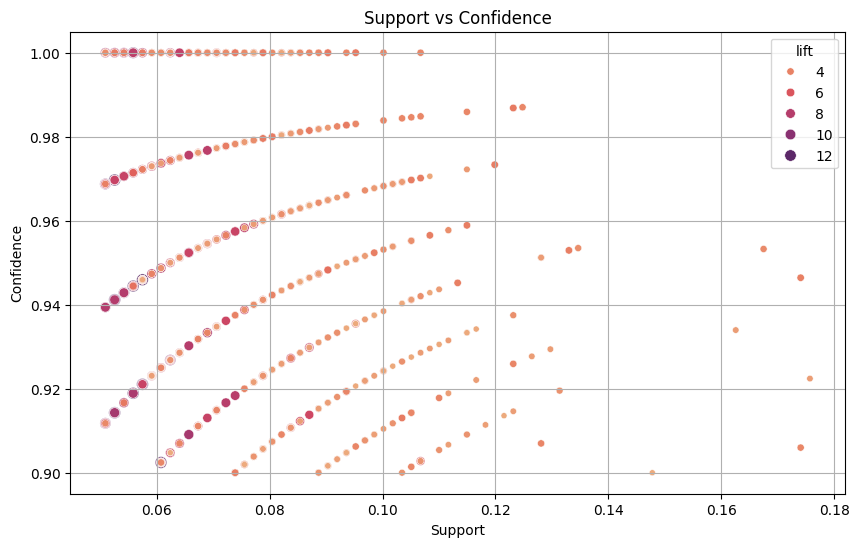

In [59]:
min_confidence = 0.9

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_confidence
)

print("Асоціативні правила:")
print(f"Мінімальний confidence: {min_confidence}")
print(f"Кількість правил: {len(rules)}")

if len(rules) > 0:

    rules_df = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()

    rules_df["rule"] = (
        rules_df["antecedents"].apply(lambda x: ", ".join(list(x))) +
        " → " +
        rules_df["consequents"].apply(lambda x: ", ".join(list(x))))

    top_rules = rules_df.sort_values(by="lift", ascending=False).head(10)

    print("\nТоп-10 правил за lift:")
    display(top_rules[["rule", "support", "confidence", "lift"]])

    print("\nАналіз правил:")
    print(f"Середній confidence: {rules['confidence'].mean():.3f}")
    print(f"Середній lift: {rules['lift'].mean():.3f}")

    plt.figure(figsize=(10, 6))

    sns.scatterplot(data=rules,x="support",y="confidence",hue="lift",size="lift",palette="flare")

    plt.title("Support vs Confidence")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.grid(True)
    plt.show()

else:
    print("Правила не знайдені")

## **ВИСНОВОК:**
Асоціативні правила можуть використовуватись у рекомендаційних системах: якщо користувачеві подобається один фільм, система пропонує інші, які часто зустрічаються разом із ним у вподобаннях інших користувачів. Високі значення confidence показують надійність таких рекомендацій, а lift дозволяє виявити неочевидні зв’язки між фільмами, які не залежать лише від їх загальної популярності. Це робить рекомендації більш релевантними та персоналізованими.

Параметри min_support і min_confidence суттєво впливають на кількість і якість правил:
При високому значенні min_support враховуються лише найпопулярніші набори, тому кількість правил значно зменшується, але їх надійність зростає.
При зниженні min_support кількість знайдених наборів різко збільшується, однак серед них можуть бути менш значущі залежності.
Високе значення min_confidence забезпечує високу точність правил, але зменшує їх кількість.
Зниження min_confidence дозволяє отримати більше правил, проте вони можуть бути менш надійними.